### Decision Tree Regressor

**Business Objective:** Build a model that predicts Power Energy generated by a powerplant based on atmospheric and humidity conditions

### Step1: Data Gathering

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
path = r'https://raw.githubusercontent.com/kavaderohan2005-netizen/Datasets/refs/heads/main/PowerPlant.csv'
import pandas as pd
df = pd.read_csv(path)
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
df.shape

(9568, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


### Separate X and Y features

**Target feature: Y -> PE: Power Energy**

    AT: Atmospheric Temperature
    V : Vaccum pressure
    AP  :Atmospheric Pressure
    RH : Relative Humidity

In [5]:
x = df.drop(columns=['PE'])
y = df[['PE']]

**Split the data into training and testing**

In [6]:
from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.75,random_state=21)
print(xtrain.shape)
print(xtest.shape)

(7176, 4)
(2392, 4)


### Data cleaning and data preprocessing


In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  StandardScaler

# create pipeline
num_pipe = make_pipeline(SimpleImputer(strategy='median'),StandardScaler()).set_output(transform='pandas')

num_pipe

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [8]:
num_pipe.fit(xtrain)

,steps,"[('simpleimputer', ...), ('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [9]:
xtrain_pre = num_pipe.transform(xtrain)
xtest_pre = num_pipe.transform(xtest)

### MOdel Building

In [10]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(xtrain_pre,ytrain)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [11]:
model.score(xtrain_pre,ytrain)

1.0

In [12]:
model.score(xtest_pre,ytest)

0.9202624932970896

### Hyperaparameter tuning

    max_depth
    criterion
    min_samples_leaf

In [13]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth':[3,4,5,7,8,10,11],
    'criterion':['squared_error','absolute_error'],
    'min_samples_leaf':[2,3,4,5]
}

gscv = GridSearchCV(model,params,cv=3,scoring='r2')
gscv.fit(xtrain_pre,ytrain)

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'absolute_error'], 'max_depth': [3, 4, ...], 'min_samples_leaf': [2, 3, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [14]:
gscv.best_params_

{'criterion': 'squared_error', 'max_depth': 8, 'min_samples_leaf': 3}

In [15]:
gscv.best_score_

np.float64(0.939667053659997)

In [16]:
best_dtr_model = gscv.best_estimator_
best_dtr_model

,criterion,'squared_error'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [17]:
best_dtr_model.score(xtrain_pre,ytrain)

0.957670976464165

In [18]:
best_dtr_model.score(xtest_pre,ytest)

0.9407022680235556

### Evaluate the model

In [19]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

ypreds= best_dtr_model.predict(xtest_pre)

mse = mean_squared_error(ytest,ypreds)
mae = mean_absolute_error(ytest,ypreds)
r2 = r2_score(ytest,ypreds)
rmse = mse**0.5

print("=============================")
print("Testing Scores")
print(f"MSE:{mse}")
print(f"RMSE:{rmse}")
print(f"MAE:{mae}")
print(f"R2:{r2*100:.2f}")

Testing Scores
MSE:17.401958165470027
RMSE:4.171565433439829
MAE:3.1126662557728553
R2:94.07


### This model can be finalised for deployment

In [20]:
import joblib
joblib.dump(num_pipe,"pipeline.joblib")
joblib.dump(best_dtr_model,"model.joblib")

['model.joblib']

### Visualize the Decision Tree

### Feature Importances

In [21]:
best_dtr_model.feature_importances_

array([0.93445495, 0.0478821 , 0.01008036, 0.00758259])

In [22]:
xtrain.columns

Index(['AT', 'V', 'AP', 'RH'], dtype='object')

In [23]:
feature_imp_data = pd.DataFrame(best_dtr_model.feature_importances_,index=xtrain.columns,columns=['Feature Importance'])
feature_imp_data

,Feature Importance
AT,0.934455
V,0.047882
AP,0.010080
RH,0.007583


In [24]:
feature_imp = pd.DataFrame([best_dtr_model.feature_importances_,xtrain.columns]).T
feature_imp.columns = ['Features','Importances']
feature_imp

,Features,Importances
0,0.934455,AT
1,0.047882,V
2,0.01008,AP
3,0.007583,RH


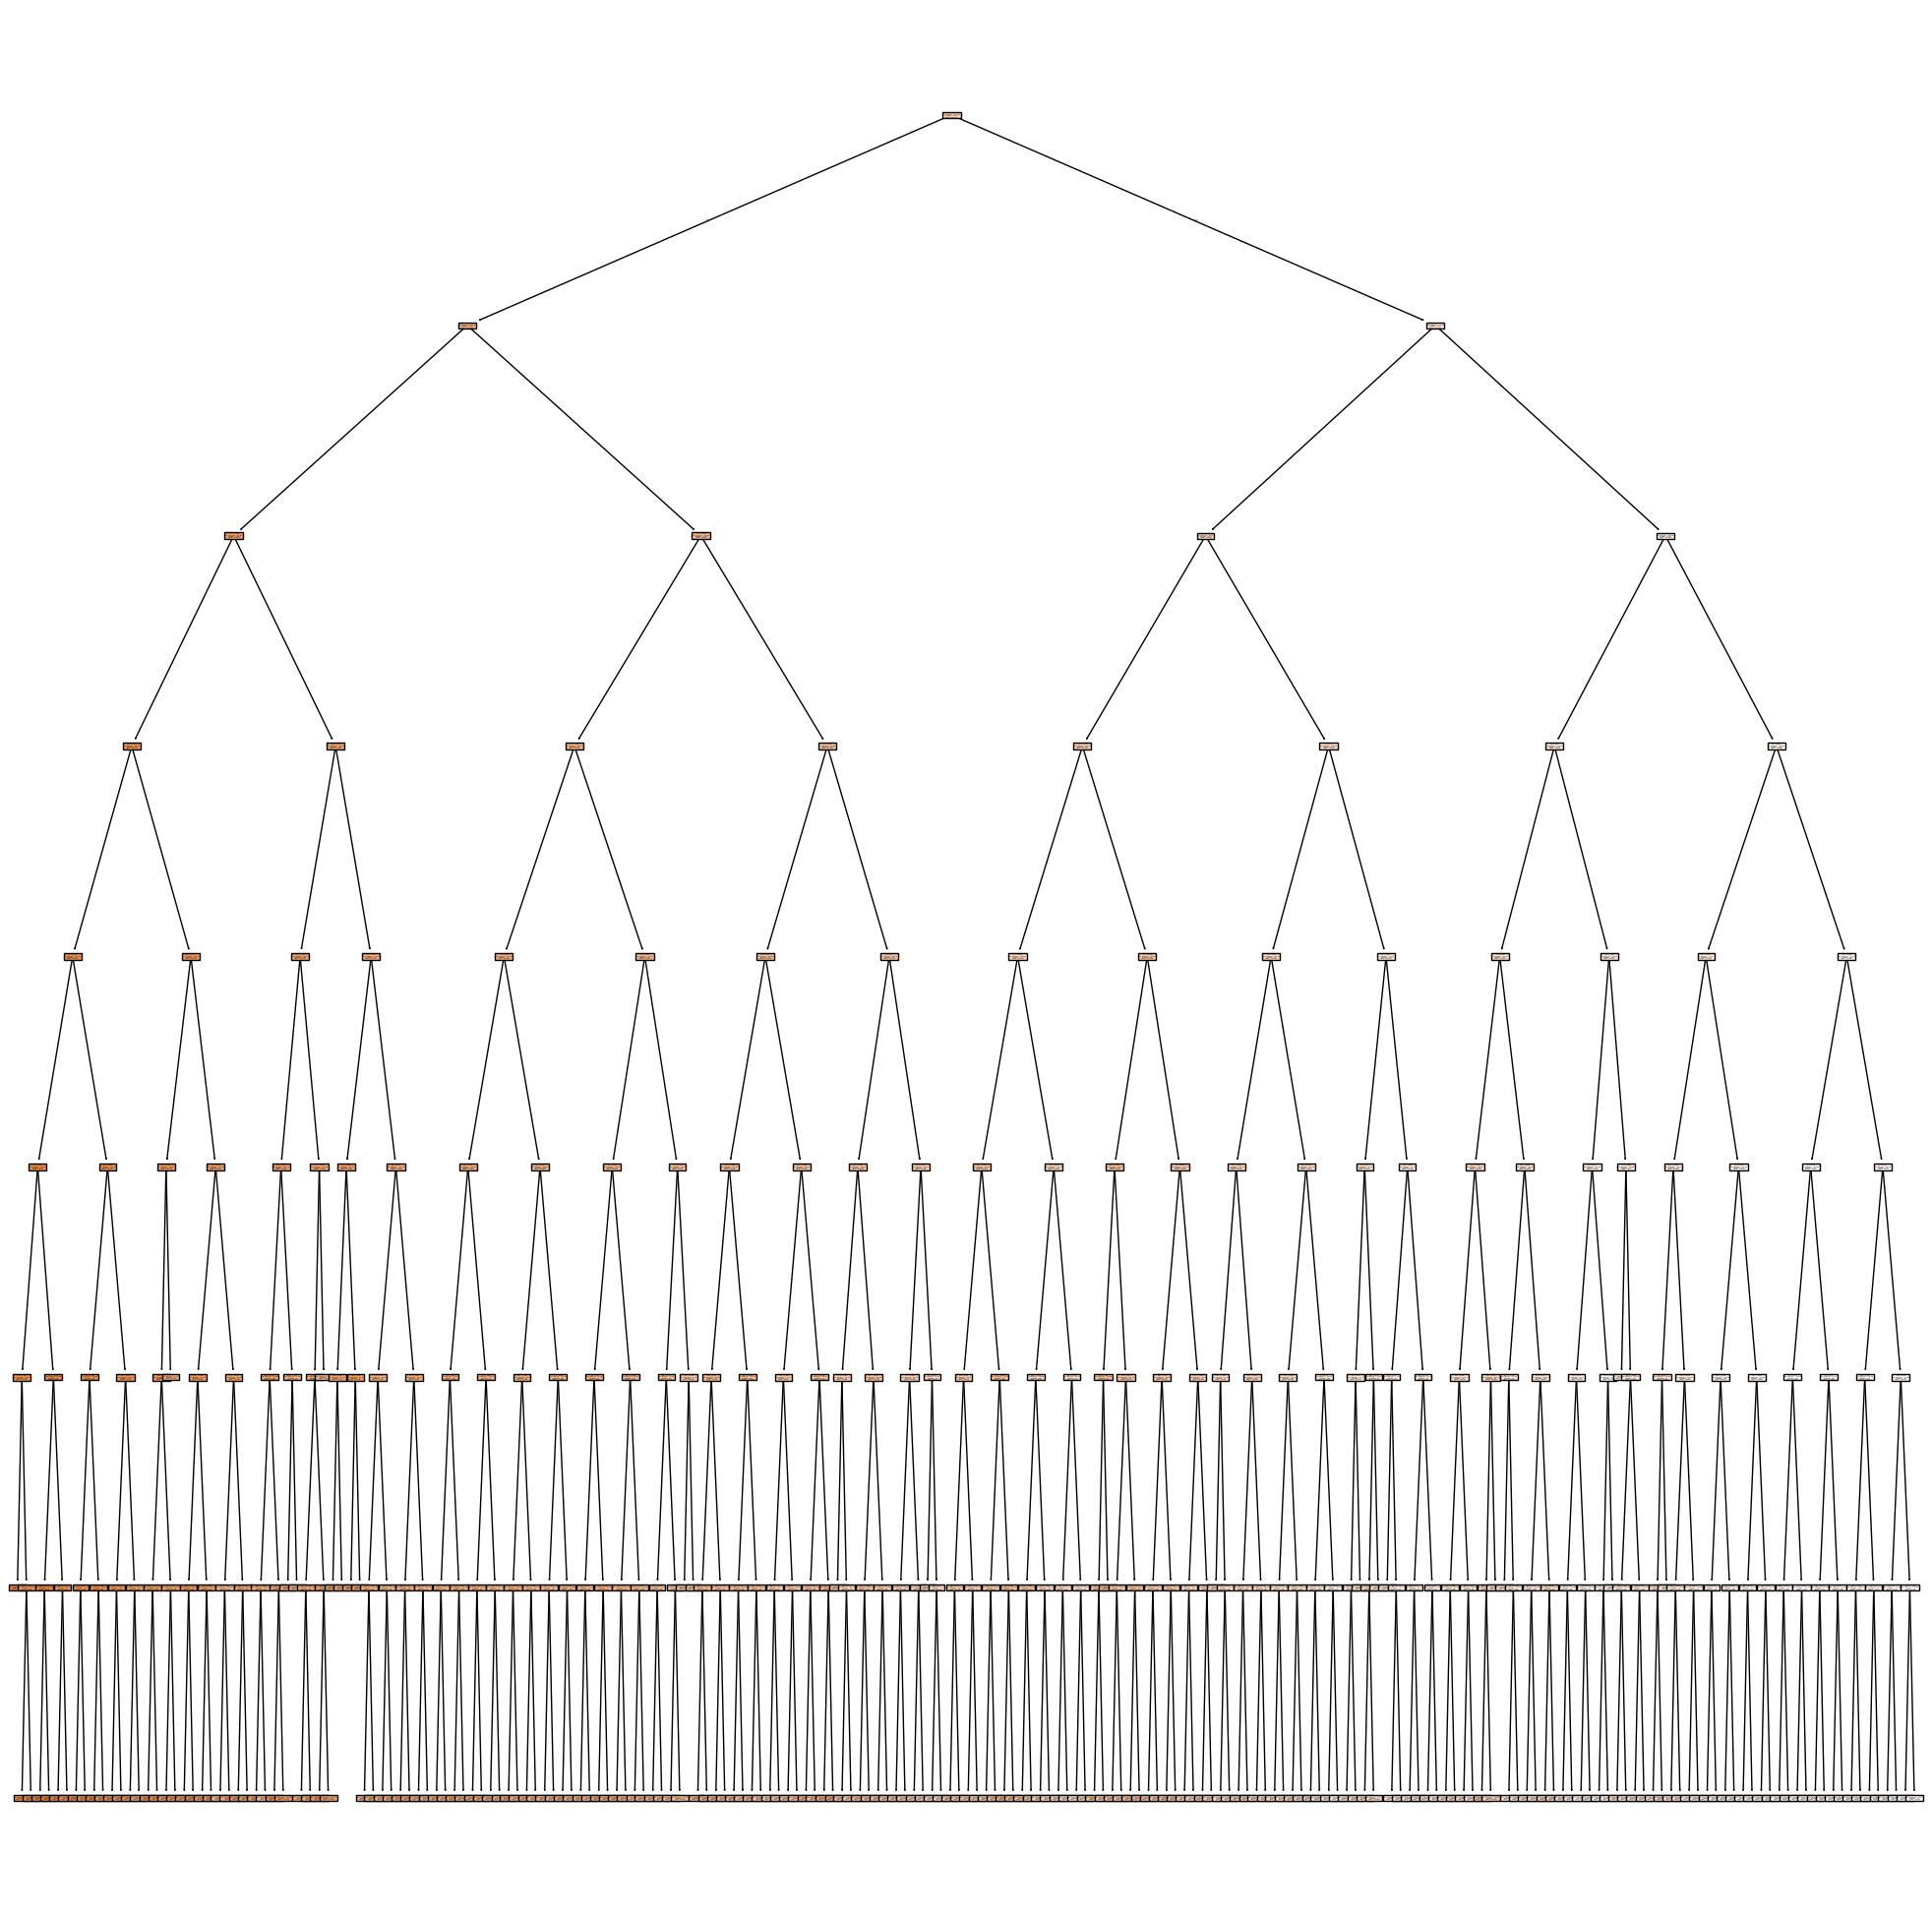

In [25]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fea_names = xtrain.columns
plt.figure(figsize=(25,25))
plot_tree(best_dtr_model,feature_names=fea_names,filled=True)
plt.show()

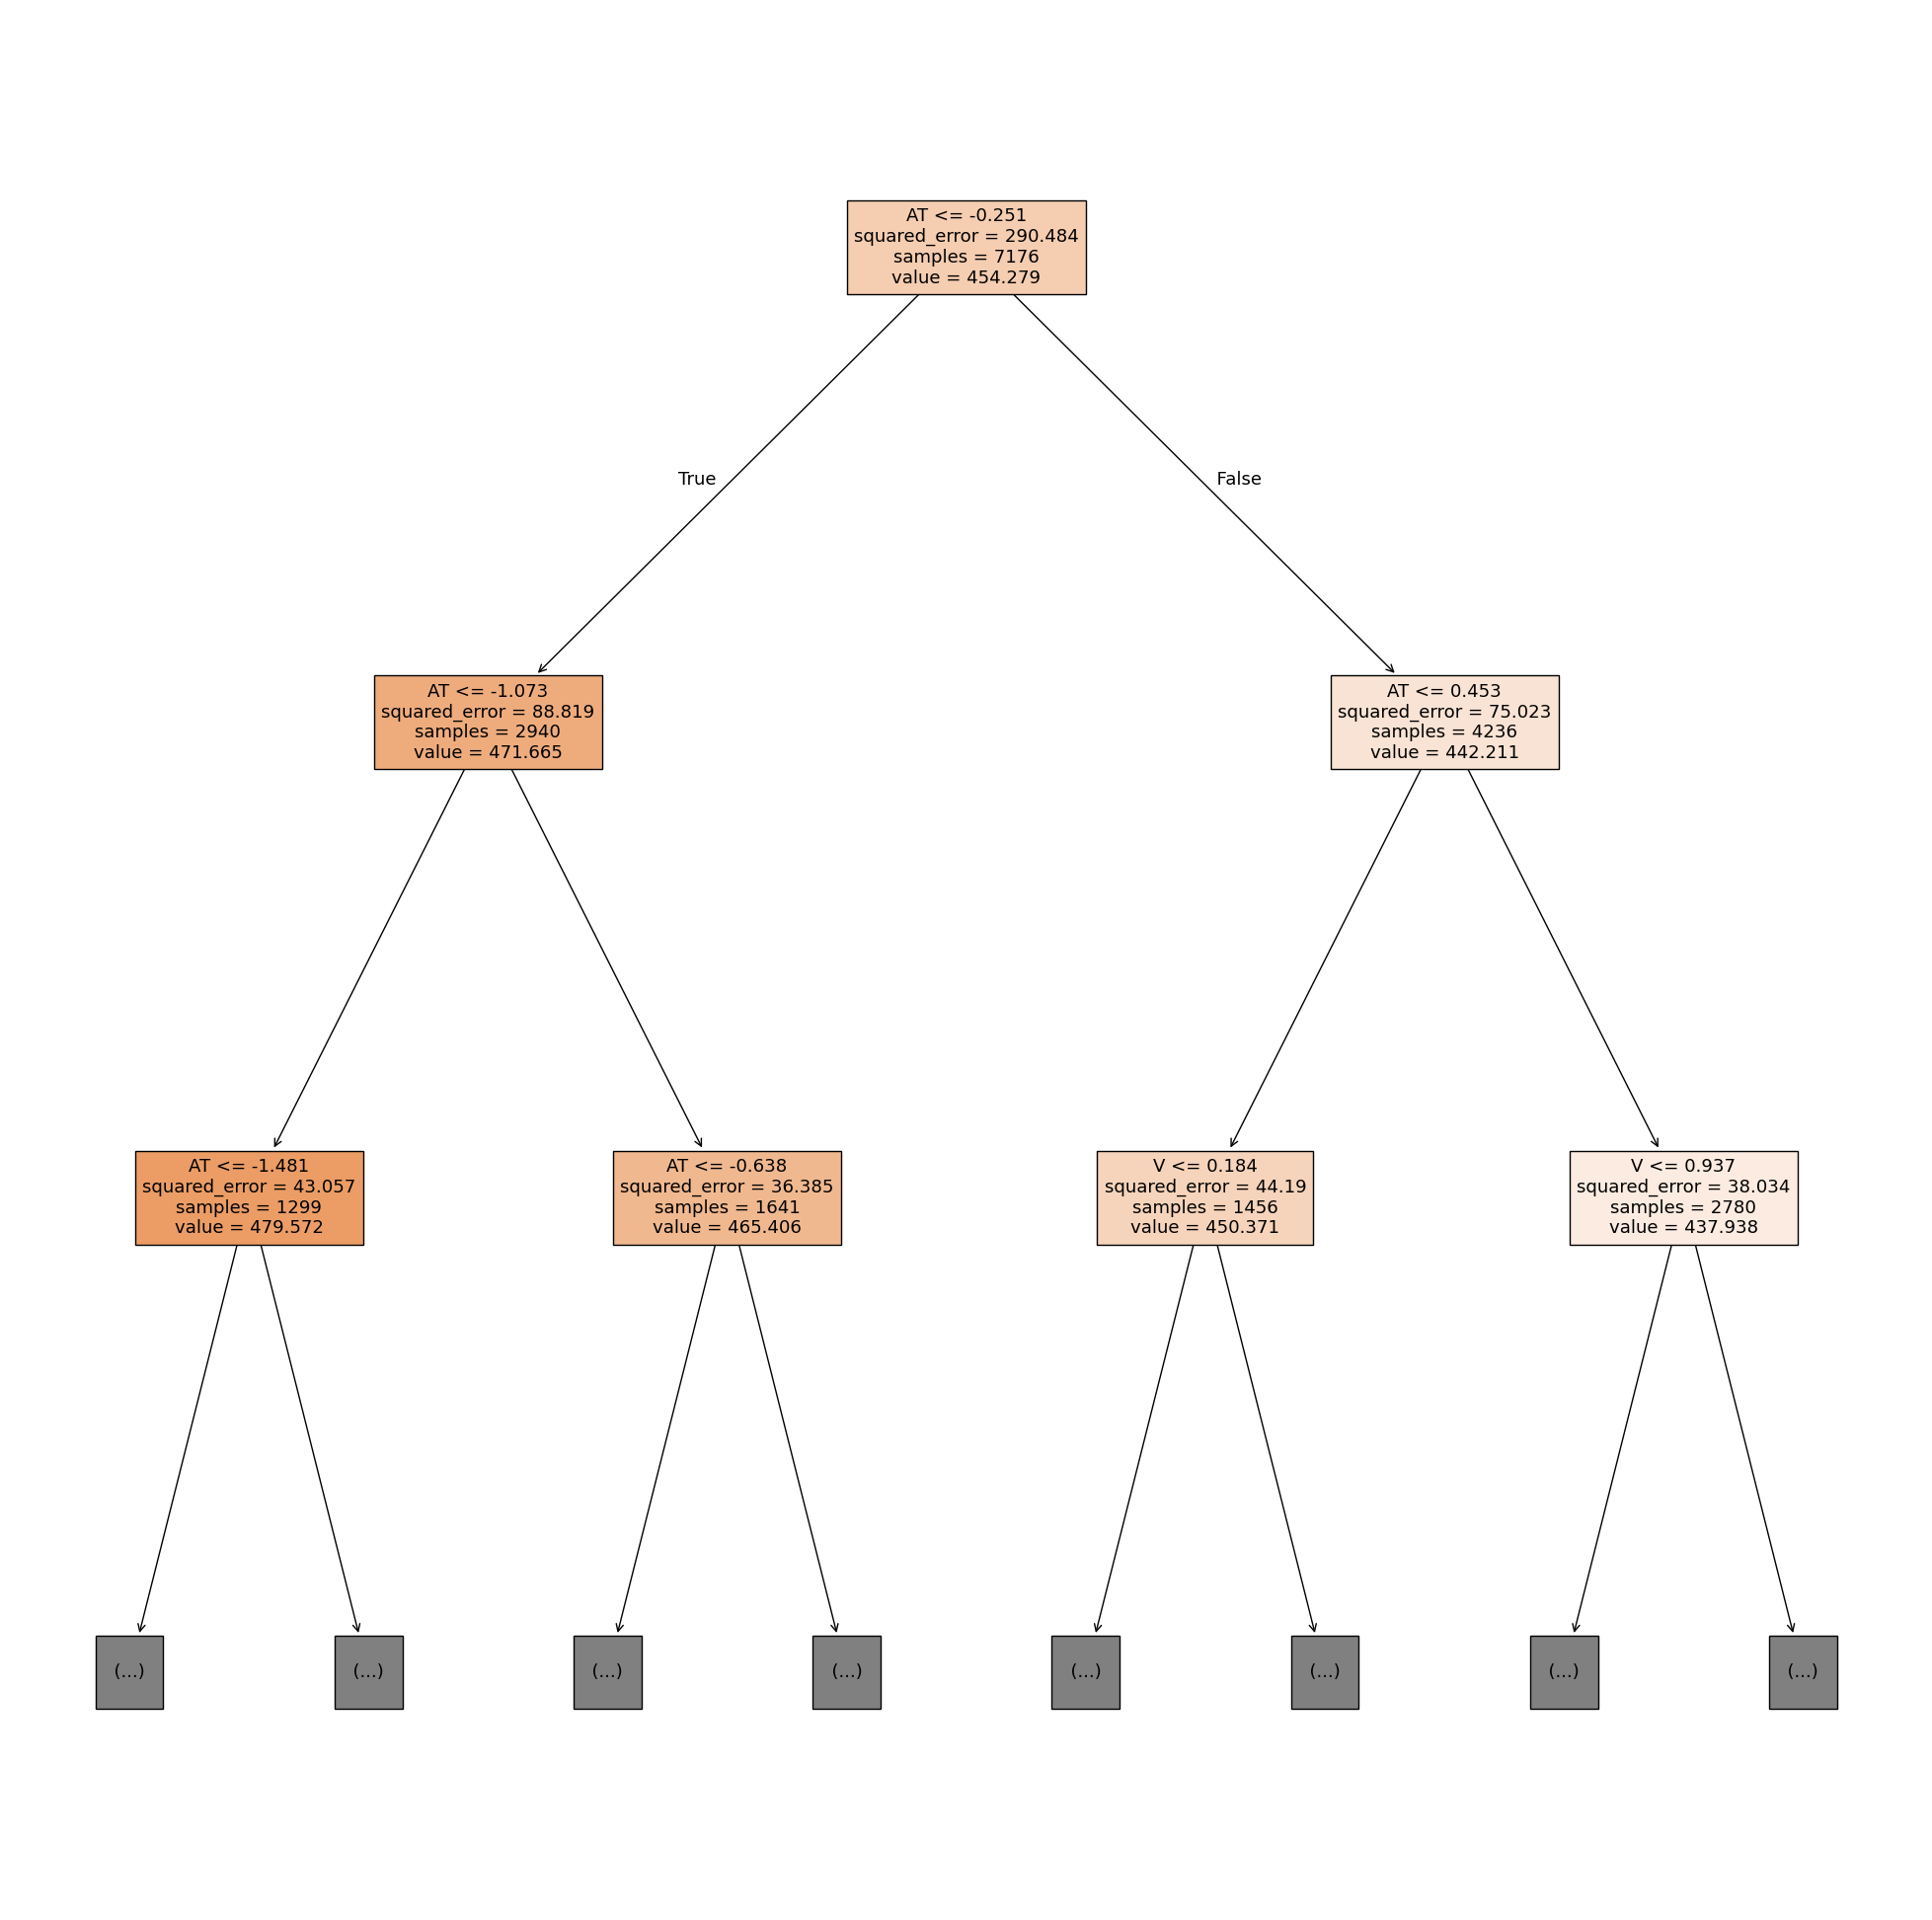

In [26]:
plt.figure(figsize=(25,25))
plot_tree(best_dtr_model,feature_names=fea_names,filled=True,max_depth=2)
plt.show()